<a href="https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/Task5_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

C VINUSHA REDDY

1CR22IS036

https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/Task5_K_Means.ipynb

# 📘 Project Title  
**Customer Segmentation using K-Means Clustering**

🔗 Dataset: https://www.kaggle.com/datasets/hanaksoy/customer-purchasing-behaviors  

---

# 🎯 Problem Statement  

In today’s competitive market, businesses need to understand their customers to deliver personalized experiences and increase revenue. However, customers differ in terms of age, income, purchasing habits, and loyalty, making it difficult to target them effectively.  

This project aims to analyze customer purchasing behavior using features such as:  
- Age  
- Annual Income  
- Purchase Amount  
- Purchase Frequency  
- Region  
- Loyalty Score  

The objective is to group customers into meaningful segments based on their similarities using K-Means Clustering.

---

# 🎯 Objectives  

By performing customer segmentation, businesses can:  

- Identify high-value and low-value customers  
- Design targeted marketing strategies  
- Improve customer retention and loyalty  
- Optimize product recommendations  

---

# 📊 Dataset Information  

The dataset used in this project is synthetic and created for learning purposes. It contains customer demographic and purchasing behavior data.

---

# 🚀 Project Steps (End-to-End)  

1. **Understanding the Problem**  
   - Define the objective  
   - Identify key features  

2. **Import Libraries & Load Data**  
   - Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn  

3. **Basic Data Checks**  
   - Check shape and data types  
   - Handle missing values  
   - Remove duplicates  

4. **Exploratory Data Analysis (EDA)**  
   - Univariate analysis  
   - Bivariate analysis  
   - Identify patterns and trends  

5. **Data Preprocessing**  
   - Encode categorical data (region)  
   - Feature scaling  

6. **Feature Selection**  
   - Select important features  

7. **Apply K-Means Clustering**  
   - Use Elbow Method to find optimal K  
   - Train model  
   - Assign clusters  
   - Evaluate performance  

---

# 🎯 Expected Outcome  

- Customers are grouped into meaningful segments  
- Better understanding of customer behavior  
- Improved business decision-making  

---

# 1.Import Libraries and Load the Dataset


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/Customer Purchasing Behaviors.csv")

# Display first 5 rows
df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


# 📊 Description of Variables

The dataset contains the following features:

- **user_id**  
  Unique identifier assigned to each customer.

- **age**  
  Age of the customer (in years). Helps in understanding customer demographics.

- **annual_income**  
  Yearly income of the customer. Indicates purchasing power and financial capacity.

- **purchase_amount**  
  Total amount spent by the customer on purchases. Reflects spending behavior.

- **loyalty_score**  
  A score representing customer loyalty. Higher values indicate more loyal customers.

- **region**  
  Geographic region where the customer belongs (categorical feature such as North, South, etc.).

- **purchase_frequency**  
  Number of times the customer makes purchases within a given time period. Indicates buying habits.

#3.Basic Data Checks

In [14]:
df.shape

(238, 7)

In [41]:
df.dtypes

,0
user_id,int64
age,int64
annual_income,int64
purchase_amount,int64
loyalty_score,float64
region,int64
purchase_frequency,int64
Cluster,int32


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


In [17]:
df.isnull().sum()

,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,23.000000
max,238.000000,55.000000,75000.000000,640.000000,9.500000,28.000000


#3.Exploratory Data Analysis

##Univariate Analysis

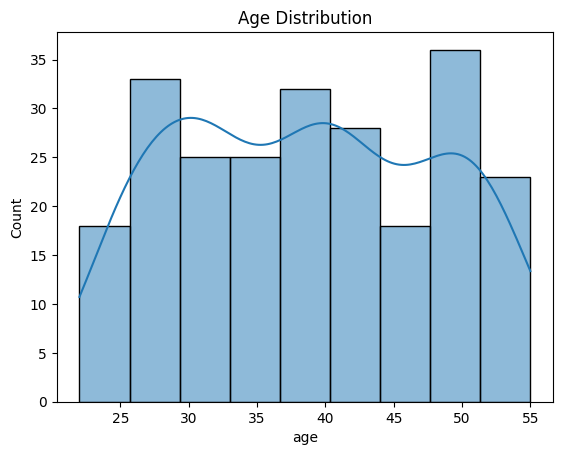

In [21]:
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

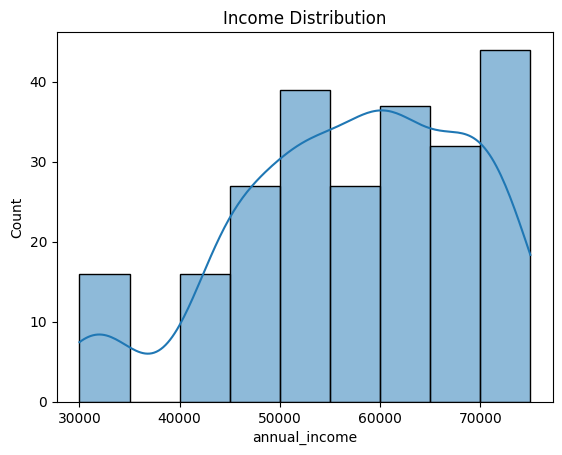

In [26]:
plt.figure()
sns.histplot(df['annual_income'], kde=True)
plt.title("Income Distribution")
plt.show()

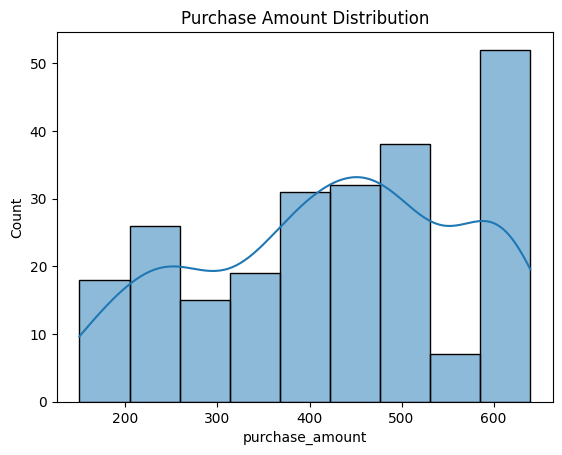

In [27]:
plt.figure()
sns.histplot(df['purchase_amount'], kde=True)
plt.title("Purchase Amount Distribution")
plt.show()

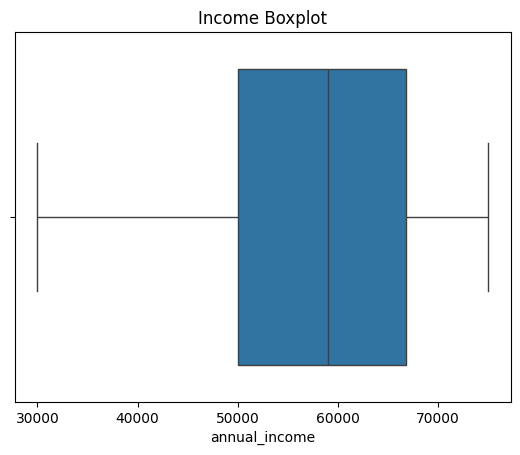

In [29]:
plt.figure()
sns.boxplot(x=df['annual_income'])
plt.title("Income Boxplot")
plt.show()

##Bivariate Analysis

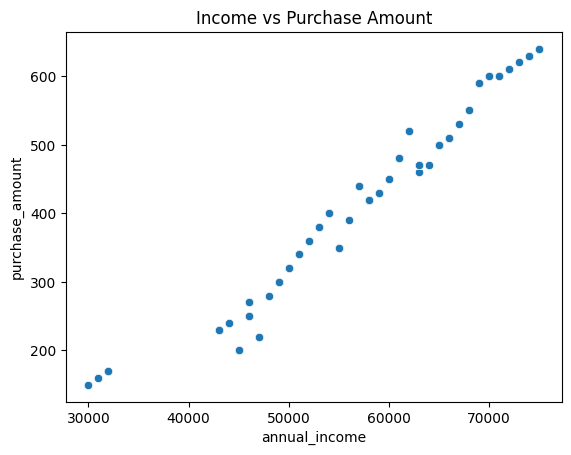

In [30]:
plt.figure()
sns.scatterplot(x=df['annual_income'], y=df['purchase_amount'])
plt.title("Income vs Purchase Amount")
plt.show()

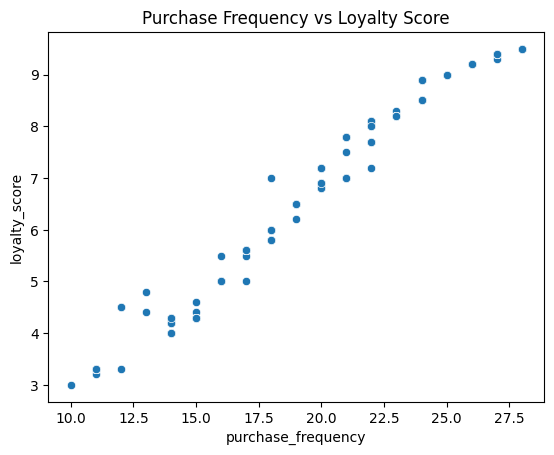

In [34]:
plt.figure()
sns.scatterplot(x=df['purchase_frequency'], y=df['loyalty_score'])
plt.title("Purchase Frequency vs Loyalty Score")
plt.show()

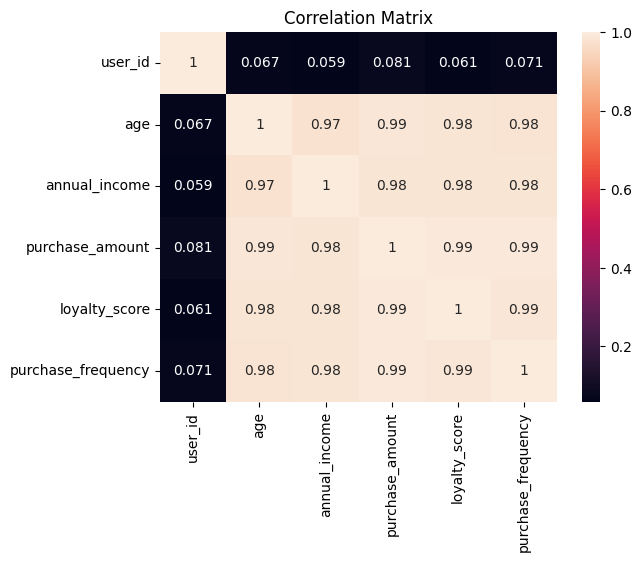

In [32]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Matrix')
plt.show()


In [37]:
# Grouping example
df.groupby('loyalty_score')['purchase_amount'].mean()

# Age group analysis
df.groupby('age')['purchase_amount'].mean().head()

,purchase_amount
age,
22,150.0
23,160.0
24,170.0
25,200.0
26,240.0


#4.Data Preprocessing and 5.Feature Selection


In [38]:
#Encode categorical column (region)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['region'] = le.fit_transform(df['region'])

df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,1,12
1,2,34,55000,350,7.0,2,18
2,3,45,65000,500,8.0,3,22
3,4,22,30000,150,3.0,0,10
4,5,29,47000,220,4.8,1,13


In [39]:
#Feature Selection
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Select features (before scaling)
features = df[['annual_income', 'purchase_amount', 'purchase_frequency', 'loyalty_score']]

X_scaled = scaler.fit_transform(features)

#6.K-MEANS Clustering

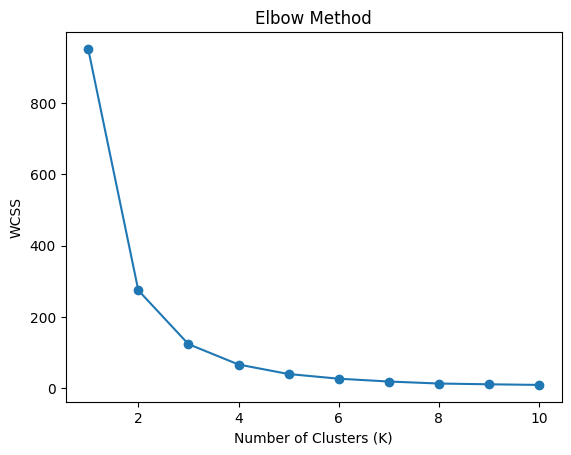

   annual_income  purchase_amount  Cluster
0          45000              200        2
1          55000              350        1
2          65000              500        3
3          30000              150        2
4          47000              220        2
Silhouette Score: 0.6057368304037589


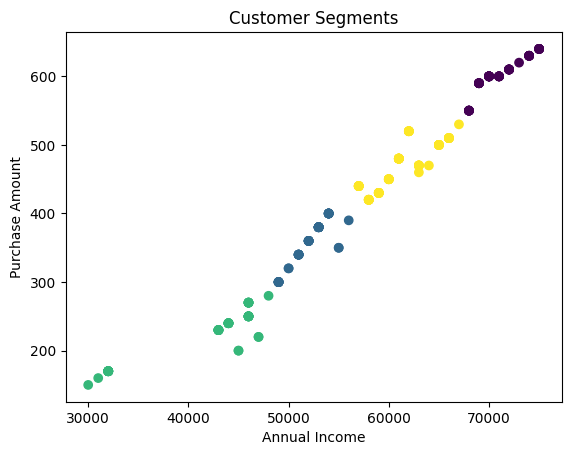

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


# ELBOW METHOD (Find Optimal K)

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()


# FINAL MODEL (Choose Best K)

optimal_k = 4   # Change based on elbow graph

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)


# ASSIGN CLUSTER LABELS

print(df[['annual_income', 'purchase_amount', 'Cluster']].head())


# EVALUATION

score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", score)


# CLUSTER VISUALIZATION

plt.figure()
plt.scatter(df['annual_income'], df['purchase_amount'], c=df['Cluster'])
plt.xlabel('Annual Income')
plt.ylabel('Purchase Amount')
plt.title('Customer Segments')
plt.show()